In [ ]:
# 📦 Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 🔁 Chargement des données
from google.colab import files
uploaded = files.upload()



Saving Cleaned_DataSet.csv to Cleaned_DataSet.csv


In [ ]:
#Prétraitement
file_name = list(uploaded.keys())[0] # Get the first uploaded file name
df = pd.read_csv(file_name) # Read the CSV file into a pandas DataFrame
X =df.drop(['S11_dB'], axis=1)
y = df['S11_dB']

In [ ]:
# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 🔀 Split des données
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 🌲 Modèle IA : Random Forest Regressor
model = RandomForestRegressor(n_estimators=150, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 📊 Évaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}, R²: {r2:.4f}")


RMSE: 0.5379, R²: 0.9782


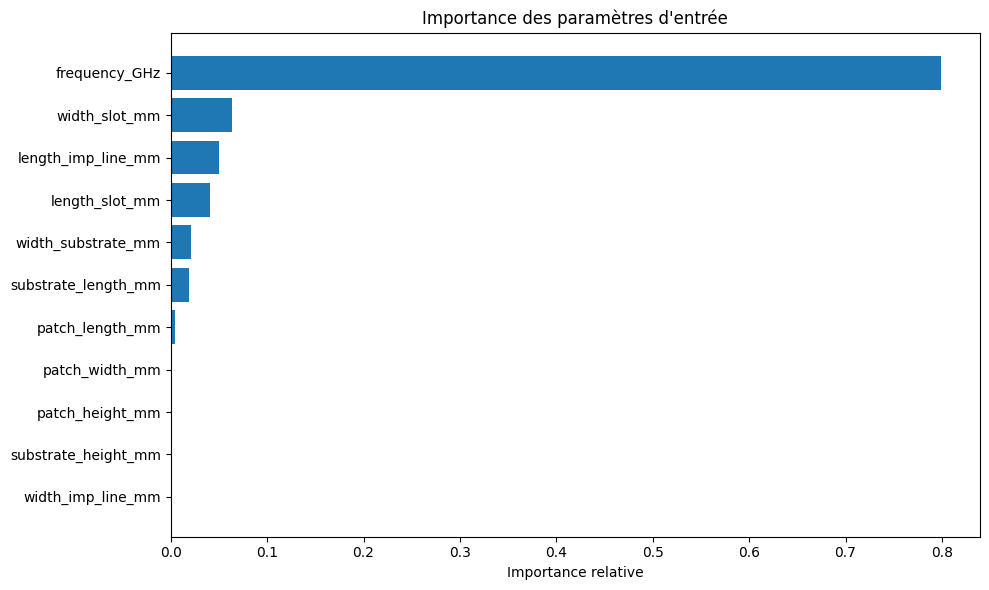

In [ ]:
# 🔍 Graphe 1 : Importance des paramètres
importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Importance des paramètres d'entrée")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Importance relative")
plt.tight_layout()
plt.show()

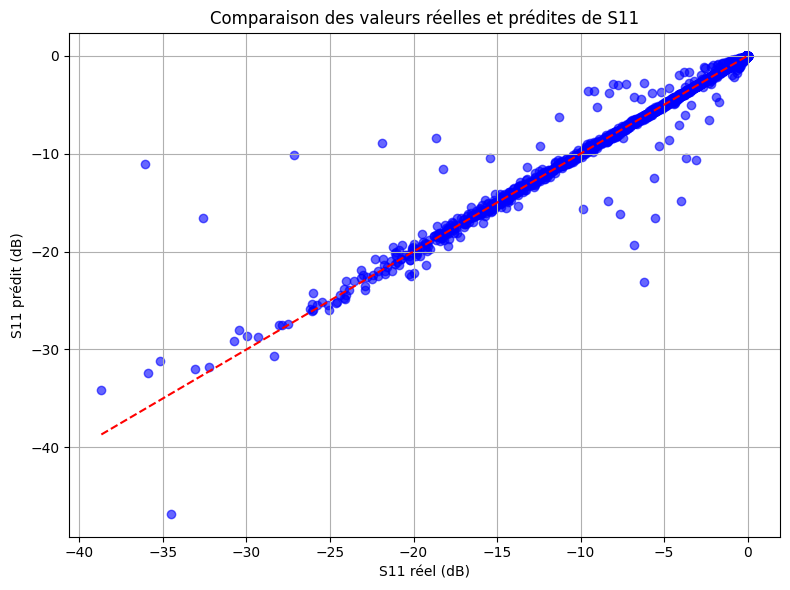

In [ ]:
# 📈 Graphe 2 : S11 réel vs prédit
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, c='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('S11 réel (dB)')
plt.ylabel('S11 prédit (dB)')
plt.title('Comparaison des valeurs réelles et prédites de S11')
plt.grid(True)
plt.tight_layout()
plt.show()

Saving Cleaned_DataSet.csv to Cleaned_DataSet (1).csv
🔍 Random Forest : RMSE=0.5379, R²=0.9782, MAE=0.0600
🔍 KNN Regressor : RMSE=0.4216, R²=0.9866, MAE=0.0495


<ipython-input-11-87595469>:60: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


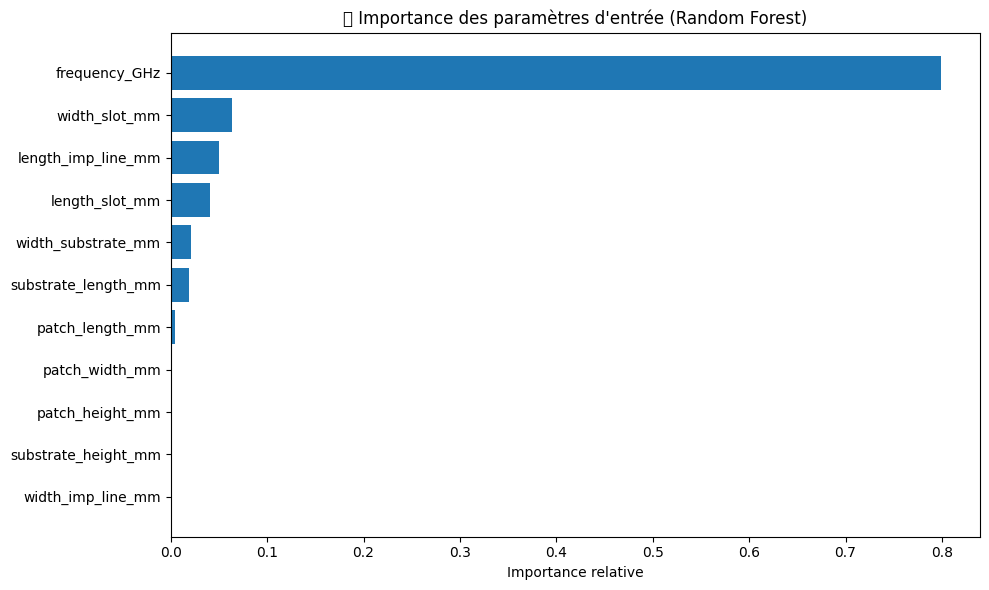

<ipython-input-11-87595469>:73: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


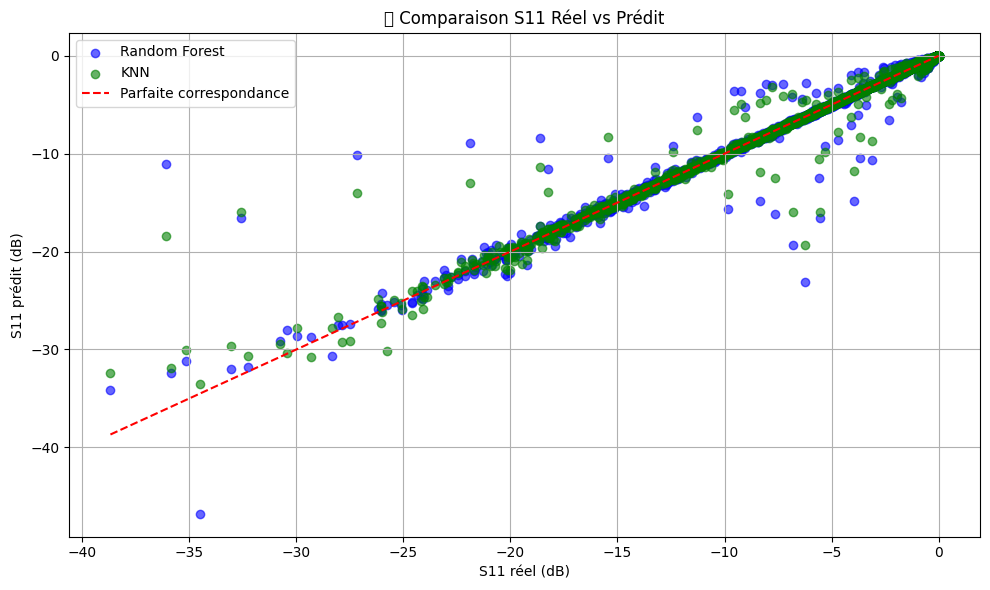

📁 Modèles et scaler sauvegardés avec succès !


ValueError: 11 columns passed, passed data had 5 columns

In [ ]:
# 📦 Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# 🔁 Chargement des données
from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# 🎯 Séparation des variables
X = df.drop(['S11_dB'], axis=1)
y = df['S11_dB']

# 🔄 Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🔀 Split données
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 🌲 Modèle 1 : Random Forest
rf_model = RandomForestRegressor(n_estimators=150, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# 🤖 Modèle 2 : KNN Regressor
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

# 📊 Évaluation comparée
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"🔍 {name} : RMSE={rmse:.4f}, R²={r2:.4f}, MAE={mae:.4f}")

evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("KNN Regressor", y_test, knn_pred)

# 🔍 Graphe importance des features (Random Forest uniquement)
importances = rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("📊 Importance des paramètres d'entrée (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Importance relative")
plt.tight_layout()
plt.show()

# 📈 Graphe S11 réel vs prédit pour les deux modèles
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_pred, alpha=0.6, label='Random Forest', color='blue')
plt.scatter(y_test, knn_pred, alpha=0.6, label='KNN', color='green')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label='Parfaite correspondance')
plt.xlabel('S11 réel (dB)')
plt.ylabel('S11 prédit (dB)')
plt.title('📈 Comparaison S11 Réel vs Prédit')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 💾 Sauvegarde des modèles
joblib.dump(rf_model, 'random_forest_s11_model.pkl')
joblib.dump(knn_model, 'knn_s11_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("📁 Modèles et scaler sauvegardés avec succès !")

# 🎯 Exemple prédiction sur nouvelle configuration
nouvelle_antenne = pd.DataFrame([[30, 50, 1.6, 2.0, 5.0]], columns=X.columns)  # à adapter
nouvelle_scaled = scaler.transform(nouvelle_antenne)
pred_rf = rf_model.predict(nouvelle_scaled)
pred_knn = knn_model.predict(nouvelle_scaled)
print(f"📡 Prédiction S11 (Random Forest) : {pred_rf[0]:.2f} dB")
print(f"📡 Prédiction S11 (KNN)           : {pred_knn[0]:.2f} dB")
